## Import Libraries

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Load and Preview Data

In [222]:
data = pd.read_csv("clean_data.csv")

print("Shape:", data.shape)
data.head()

Shape: (2620, 8)


,price,area,status,bhk,bathroom,age,location,builder
0,37.49,872,Ready to move,2,NaN,1.0,Sembakkam,MP Developers
1,93.54,1346,Under Construction,3,2.0,NaN,Selaiyur,DAC Promoters
2,151.00,2225,Under Construction,3,NaN,0.0,Mogappair,Casagrand Builder Private Limited
3,49.00,1028,Ready to move,2,2.0,3.0,Ambattur,Dugar Housing Builders
4,42.28,588,Under Construction,2,1.0,0.0,Pallavaram,Radiance Realty Developers India Ltd


## Data Information

In [223]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   price     2620 non-null   float64
 1   area      2620 non-null   int64  
 2   status    2620 non-null   object 
 3   bhk       2620 non-null   int64  
 4   bathroom  1403 non-null   float64
 5   age       1729 non-null   float64
 6   location  2620 non-null   object 
 7   builder   2620 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 163.9+ KB


## Check for Missing Values

In [224]:
data.isnull().sum()

,0
price,0
area,0
status,0
bhk,0
bathroom,1217
age,891
location,0
builder,0


## Handle Missing Values

In [225]:
# Fill numerical columns
num_cols = data.select_dtypes(include=['number']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical columns ONLY if they exist
cat_cols = data.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    for col in cat_cols:
        data[col] = data[col].fillna(data[col].mode()[0])

## Visualize Price Distribution

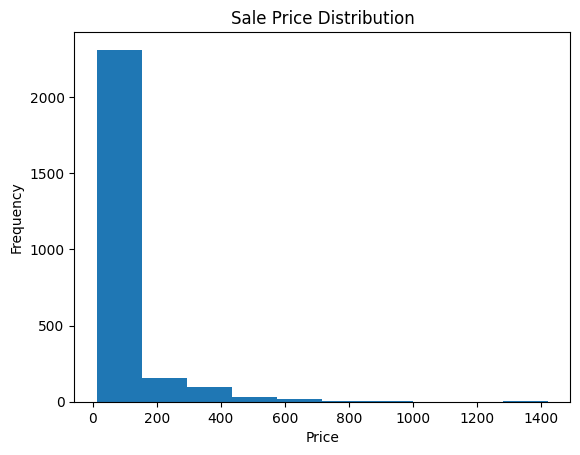

In [226]:
plt.hist(data["price"])
plt.title("Sale Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Correlation Heatmap of Numeric Features

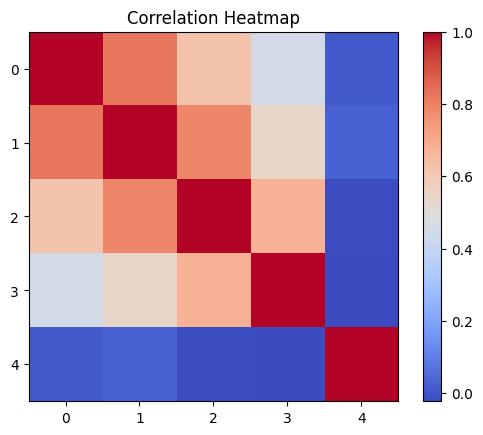

In [227]:
numeric_data = data.select_dtypes(include=['number'])

plt.imshow(numeric_data.corr(), cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

## Feature vs. Price Scatter Plot

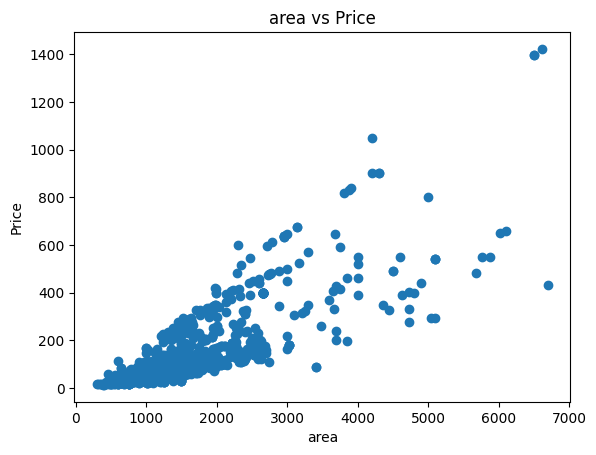

In [228]:
feature = "area"   # best simple feature

plt.scatter(data[feature], data["price"])
plt.xlabel(feature)
plt.ylabel("Price")
plt.title(f"{feature} vs Price")
plt.show()

## Drop Redundant Columns (if any)

In [229]:
if "Id" in data.columns:
    data = data.drop("Id", axis=1)

## One-Hot Encode Categorical Features

In [230]:
data = pd.get_dummies(data)

## Identify Important Features

In [231]:
correlation = data.corr()

important_features = correlation["price"].abs().sort_values(ascending=False)
selected_features = important_features.index[1:6]

print("Selected Features:", selected_features)

Selected Features: Index(['area', 'bhk', 'builder_Vinay Asrani', 'bathroom',
       'location_Royapettah'],
      dtype='object')


## Visualize Top Features

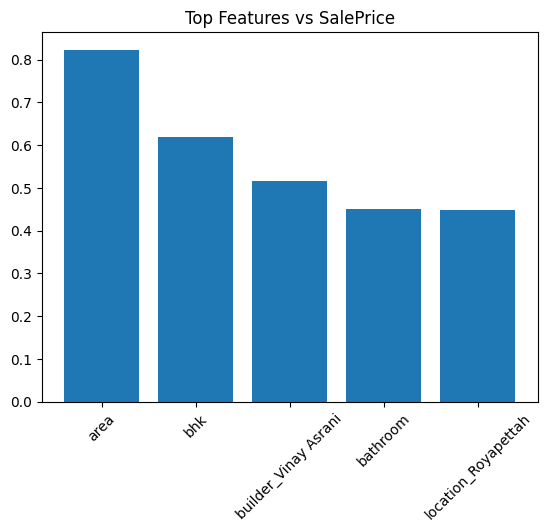

In [232]:
plt.bar(range(len(selected_features)), important_features[1:6])
plt.xticks(range(len(selected_features)), selected_features, rotation=45)
plt.title("Top Features vs SalePrice")
plt.show()

## Define Features (X) and Target (y)

In [233]:
X = data[selected_features]
y = data["price"]

## Re-evaluate and Handle Missing Values

In [234]:
# Fill numerical columns with mean
num_cols = data.select_dtypes(include=['number']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical columns safely
cat_cols = data.select_dtypes(include=['object']).columns

for col in cat_cols:
    if data[col].isnull().sum() > 0:
        mode_val = data[col].mode()
        if not mode_val.empty:
            data[col] = data[col].fillna(mode_val[0])

## Split Data into Training and Testing Sets

In [235]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Initialize and Train Linear Regression Model

In [236]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Make Predictions

In [237]:
predictions = model.predict(X_test)


## Visualize Actual vs. Predicted Prices

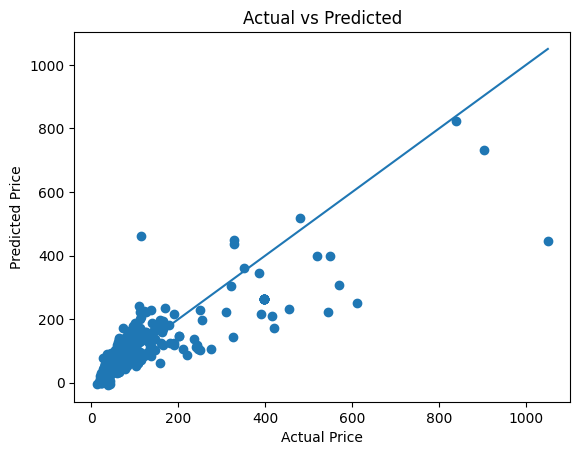

In [238]:
plt.scatter(y_test, predictions)

# Ideal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

## Display Sample Predictions

In [239]:
print("Predicted:", predictions[:5])
print("Actual:", y_test.values[:5])

Predicted: [62.02380138 78.15514663 14.9738699  46.90217121 41.22636683]
Actual: [72.42 55.   35.   75.   54.03]


## Evaluate Model Performance

In [240]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 31.935820504065255
MSE: 3619.7120976896526
RMSE: 60.16404322923828
R2 Score: 0.7041713956914564
